# 论文模型的中介效应模拟比较

**R / IRkernel · 先生成可读取文件，再运行方法 · HDMT / MDACT / MLFDR · 新方法插件接口**

依据 Roy & Zhang (2026), *Powerful large scale inference in high dimensional mediation analysis*，第2.2节、式(3)–(5)、图2–4，以及第5节的四成分高斯模型和 local FDR step-up。[论文链接](https://doi.org/10.1371/journal.pcbi.1013880)。作者代码仅用于理解接口和MDACT实现。

**本版属于论文模型下的信号增强实验，不能称为原图的严格复现。** 保留正文的三种模型、m=1000、n=300、稀疏/密集比例、X分布、系数噪声方差和误差分布，只把非零α的均值从0.05τ改为0.35τ。τ取原网格中的1.1、1.5、1.9，每条件40次，共720份数据、2160次方法调用。正文的字面参数功效极低，旧结果完整保存在 `notebooks/archive/01_weak_signal_demo.ipynb`，原因和复核见 `docs/RESULTS_AUDIT.md`。

试运行使用独立种子20261005，并保留包括异常在内的全部结果。下方正式比较使用固定种子20261006，不删除重复、不替换基础种子、不按方法排名筛选数据。最终种子映射使用不受Windows字符环境影响的v2序列化哈希；编码问题修复前的两轮比较也独立保留。所有方法接收相同的观测数据；真值仅在运行后评估使用。

**顺序**：调整参数 → 生成全部RDS和示例CSV → 从文件重新读取 → 运行方法 → 查看FDR、功效、配对差异和拟合诊断。直接阅读时保留的输出来自本机真实运行。

In [1]:
find_project_root <- function(start = getwd()) {
  path <- normalizePath(start, winslash = "/", mustWork = TRUE)
  for (i in 1:6) {
    if (file.exists(file.path(path, "R", "bootstrap.R"))) return(path)
    candidate <- file.path(path, "mlfdr_simulation_lab")
    if (file.exists(file.path(candidate, "R", "bootstrap.R"))) return(candidate)
    path <- dirname(path)
  }
  stop("请从工程或 notebooks 目录启动 Jupyter。")
}
PROJECT_ROOT <- find_project_root()
source(file.path(PROJECT_ROOT, "R", "bootstrap.R"), encoding = "UTF-8")
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 145,
        repr.matrix.max.rows = 40, repr.matrix.max.cols = 15)
check_dependencies()

# 所有主要参数集中在此处。生成参数变化 -> 新数据；方法/q变化 -> 复用数据。
config <- default_config("paper_comparison")
config$seed <- 20261006L
config$dgp_profile <- "paper_adjusted"
config$m <- 1000L
config$n <- 300L
config$tau <- c(1.1, 1.5, 1.9)
config$repetitions <- 40L
config$scenarios <- c("linear", "confounded", "binary")
config$mixtures <- list(sparse = c(H00=.88, H10=.05, H01=.05, H11=.02),
                        dense = c(H00=.40, H10=.20, H01=.20, H11=.20))
config$exposure_probability <- .1
config$alpha_mean_scale <- .35    # 唯一增强的DGP系数：正文为.05
config$beta_mean_scale <- -.5
config$alpha_noise_variance <- 1  # 实际生成方差=1/n
config$beta_noise_variance <- 4   # 实际生成方差=4/n
config$direct_mean <- 1
config$direct_sd <- sqrt(.5)
config$error_sd_m <- 1
config$error_sd_y <- 1
config$confounder_max <- .5
config$q <- .05
config$methods <- c("HDMT", "MDACT", "MLFDR")
config$method_options <- list(
  HDMT = list(exact=0L),
  MDACT = list(),
  MLFDR = list(engine="paper_em", eps=1e-4, max_iter=2000L, n_starts=3L)
)
config$workers <- 4L             # Windows PSOCK；可改为1，数据/种子不变
config$export_first_long_csv <- TRUE
validate_config(config)
estimate_storage(config)

,package,version
,<chr>,<chr>
HDMT,HDMT,1.0.5
MLFDR,MLFDR,0.1.0
NMOF,NMOF,2.11.0
ggplot2,ggplot2,4.0.3
IRkernel,IRkernel,1.3.2


datasets,method_fits,raw_matrix_GiB
<int>,<int>,<dbl>
720,2160,3.219


## 模拟数据如何设计

每份数据有n名受试者和m条中介—结局路径，矩阵的行是受试者、列是路径。X在所有路径共享，每条路径有自己的M_i和Y_i，与论文的路径筛选模型一致。

先按给定概率抽样状态H00、H10、H01、H11。H00的α、β均为0；H10仅α非零；H01仅β非零；H11两者非零，是唯一真实中介备择。非零系数独立生成：

\[
\alpha_i=0.35\tau+h_i,\quad h_i\sim N(0,1/n),\qquad
\beta_i=-0.5\tau+g_i,\quad g_i\sim N(0,4/n).
\]

注意R的`rnorm`第三个参数是标准差，所以这里用`sqrt(1/n)`、`sqrt(4/n)`。直接效应γ_i~N(1,0.5)，第二参数按方差解释；两个连续模型的误差独立N(0,1)。

| 项目 | 论文正文 | 本次正式比较 |
|:--|:--|:--|
| 线性、混杂、二元模型 | 式(3)、(4)、(5) | 模型结构相同 |
| m、n | m=1000，n∈{100,300} | m=1000，选n=300 |
| 稀疏/密集状态概率 | (0.88,0.05,0.05,0.02)/(0.4,0.2,0.2,0.2) | 相同 |
| X、Z | Ber(0.1)、N(0,1) | 相同 |
| 非零α均值 | 0.05τ | **0.35τ，明确增强** |
| 非零β均值 | −0.5τ | 相同 |
| 系数噪声方差 | 1/n、4/n | 相同 |
| γ及误差 | N(1,0.5)、独立N(0,1) | 相同 |
| τ | 0.1:0.2:1.9 | 取1.1、1.5、1.9 |
| 重复 | 正文未明确；参考代码为250 | 40，报告MCSE和区间 |

三种模型：

1. **线性**：M_i=α_iX+e_i；Y_i=β_iM_i+γ_iX+ε_i。
2. **已测混杂**：Z~N(0,1)，M增加θ_iZ，Y增加δ_iZ，θ_i、δ_i独立U(0,0.5)；两个回归都调整Z。
3. **二元结局**：M同线性模型，Y_i~Bernoulli(plogis(β_iM_i+γ_iX))；α用OLS，β用logistic回归。

α增强的理由是可检测性：n=300时α标准误约1/√(300×0.1×0.9)=0.192。正文最大τ的均值0.095低于标准误；当前均值随τ为0.385、0.525、0.665，对应约2.0、2.7、3.5个标准误，形成中等到较强的信号。它不是保证某一方法获胜的规则。

## 先生成并保存全部数据

此单元只生成和保存原始数据，不运行比较方法。RDS保留矩阵、元数据和真值；`example_long.csv`是第一份数据的可读长表，另有`example_long_truth.csv`。完整文件索引为`manifest.csv`。生成指纹、每份种子和MD5支持复用与核查；重复执行不会覆盖不同参数的数据。

In [2]:
generated <- generate_data_files(config, PROJECT_ROOT)
MANIFEST_PATH <- file.path(generated$directory, "manifest.rds")
cat("数据入口：", MANIFEST_PATH, "\n")
cat("原始数据份数：", nrow(generated$design), "\n")
head(generated$design[, c("case_id", "scenario", "mixture", "n", "tau", "replicate", "seed", "file")], 8)

Data saved/checked: 1/720



Data saved/checked: 20/720



Data saved/checked: 40/720



Data saved/checked: 60/720



Data saved/checked: 80/720



...

Data saved/checked: 700/720



Data saved/checked: 720/720



数据入口： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/data/data_9b26d93856e4/manifest.rds 


原始数据份数： 720 


,case_id,scenario,mixture,n,tau,replicate,seed,file
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<chr>
1,linear_sparse_n300_t01_r0001,linear,sparse,300,1.1,1,53862211,linear_sparse_n300_t01_r0001.rds
2,confounded_sparse_n300_t01_r0001,confounded,sparse,300,1.1,1,156366376,confounded_sparse_n300_t01_r0001.rds
3,binary_sparse_n300_t01_r0001,binary,sparse,300,1.1,1,134340448,binary_sparse_n300_t01_r0001.rds
4,linear_dense_n300_t01_r0001,linear,dense,300,1.1,1,156204632,linear_dense_n300_t01_r0001.rds
5,confounded_dense_n300_t01_r0001,confounded,dense,300,1.1,1,126490958,confounded_dense_n300_t01_r0001.rds
6,binary_dense_n300_t01_r0001,binary,dense,300,1.1,1,143781592,binary_dense_n300_t01_r0001.rds
7,linear_sparse_n300_t02_r0001,linear,sparse,300,1.5,1,185071062,linear_sparse_n300_t02_r0001.rds
8,confounded_sparse_n300_t02_r0001,confounded,sparse,300,1.5,1,12773480,confounded_sparse_n300_t02_r0001.rds


## 从文件重新读取，再进行分析

`MANIFEST_PATH`可以改成此前生成的manifest路径，但数据配置必须与config一致。算法输入只包含观测和估计量，评估阶段才读取潜在状态。

In [3]:
manifest <- read_manifest(MANIFEST_PATH)
example_data <- read_dataset(manifest, manifest$design$case_id[1])
data.frame(n=nrow(example_data$M), m=ncol(example_data$M),
           X_ones=sum(example_data$X), genuine_mediators=sum(example_data$truth$is_nonnull))
head(utils::read.csv(file.path(manifest$directory, "example_long.csv")), 8)

n,m,X_ones,genuine_mediators
<int>,<int>,<int>,<int>
300,1000,32,16


,subject_id,pathway_id,X,Z,M,Y
,<int>,<chr>,<int>,<lgl>,<dbl>,<dbl>
1,1,pathway_0001,0,NA,-0.202805099,1.8857370
2,2,pathway_0001,0,NA,1.381156414,-0.9156683
3,3,pathway_0001,0,NA,2.091688930,-0.3007868
4,4,pathway_0001,1,NA,-0.008156109,0.9841044
5,5,pathway_0001,0,NA,1.353161480,0.7909546
6,6,pathway_0001,0,NA,1.384805546,-1.1972964
7,7,pathway_0001,0,NA,-0.442662190,0.0279432
8,8,pathway_0001,0,NA,-0.291590902,-0.5526255


## 三种方法及其功能

- **HDMT**：调用已安装包的`null_estimation`、`fdr_est(exact=0)`，按最大p值筛选；与论文HDMT/JS-mixture比较对象对应。
- **MDACT**：使用作者提供的MDACT FDR阈值实现。F00的数值积分替换为同一零假设分布的解析CDF，解决一次积分失败；其统计公式和阈值搜索保留。原文件、来源、变更与验证在`vendor/PROVENANCE.md`记录。
- **MLFDR**：按论文式(14)、(18)、(30)拟合H00/H10/H01/H11四成分高斯混合模型，并按排序后的local FDR累计均值≤q选择最大合格集合。本版默认使用`paper_em`：√n缩放、log密度、向量化EM、包含0的先验方差搜索，以及3个固定初始化。起点仅按观测似然选择，不使用真值、FDR或功效。记录收敛、拟合权重、方差和起点；这是论文同一模型的数值实现，不是修改原包默认结果后冒充原包输出。可在参数区切换`engine="package"`调用已安装MLFDR包。

所有方法用同一套OLS/logistic系数与SE²。回归含截距；混杂场景正确加入Z。方法失败记为NA并单独报告；不作为0计入平均。已通过OLS与lm等价检查，以及EM似然递增、混合模型恢复、尺度不变和step-up边界检查。

In [4]:
registry <- load_method_registry(PROJECT_ROOT)
registry_info(registry[config$methods])
example_estimates <- estimate_coefficients(example_data)$estimates
input_check <- make_method_input(example_data, example_estimates)
stopifnot(!("truth" %in% names(input_check)))
head(example_estimates, 6)

,method,adapter_version,packages,description
,<chr>,<chr>,<chr>,<chr>
HDMT,HDMT,1.0.0,HDMT,HDMT::fdr_est (paper uses exact=0)
MDACT,MDACT,1.1.0,HDMT,Author MDACT FDR threshold with equivalent analytic null CDF
MLFDR,MLFDR,2.0.0,MLFDR,Paper four-state EM or MLFDR::localFDR + adaptive step-up; engine in config


,pathway_id,alpha_hat,beta_hat,var_alpha,var_beta,se_alpha,se_beta,p_alpha,p_beta
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0001,pathway_0001,-0.374242388,-0.066346692,0.03299602,0.003687385,0.1816481,0.06072384,0.04024155,0.27545620
pathway_0002,pathway_0002,0.005754052,0.015977176,0.03784218,0.003390098,0.1945307,0.05822455,0.97642249,0.78396325
pathway_0003,pathway_0003,-0.116290730,0.097351471,0.03529902,0.003011376,0.1878803,0.05487601,0.53641446,0.07708333
pathway_0004,pathway_0004,-0.016848380,0.019490948,0.03522038,0.003618104,0.1876709,0.06015068,0.92852539,0.74613933
pathway_0005,pathway_0005,0.097473535,0.008193637,0.03821683,0.003055420,0.1954913,0.05527586,0.61842327,0.88226046
pathway_0006,pathway_0006,-0.134377076,-0.079471721,0.03409118,0.003474981,0.1846380,0.05894897,0.46731555,0.17863924


## 读取已保存的数据，运行方法并汇总

每次重复计算：发现数R、假发现V、真发现S、真实备择数A；FDP=V/max(R,1)，power=S/A。**经验FDR是逐次FDP的平均**，不是把所有V、R合并后相除。MCSE=重复间SD/√B。图中阴影为近似95%蒙特卡洛均值区间；全0或全1的边界样本使用保守端点界，避免零宽区间。

每种方法共享相同数据，功效差异另按同一次重复配对计算，输出差值及其区间。q=0.05是目标，不是强制截断结果的上限；超出目标的实际值照常保留。数据、拟合和方法结果分别缓存，新增方法不重新生成数据。

In [5]:
experiment <- run_experiment(manifest, config, PROJECT_ROOT, registry)
artifacts <- save_comparison_artifacts(experiment, PROJECT_ROOT)
summary_table <- experiment$summary
atomic_save_rds(list(output_dir=experiment$output_dir, manifest_path=MANIFEST_PATH,
                     config=config), file.path(PROJECT_ROOT, "docs", "current_comparison.rds"))
cat("结果目录：", experiment$output_dir, "\n")
cat("成功调用：", sum(experiment$metrics$status == "ok"), "/", nrow(experiment$metrics), "\n")
cat("有警告的调用：", sum(nzchar(experiment$metrics$warning)), "\n")

Analysed 12/720 saved datasets; method errors: 0



Analysed 24/720 saved datasets; method errors: 0



Analysed 36/720 saved datasets; method errors: 0



Analysed 48/720 saved datasets; method errors: 0



Analysed 60/720 saved datasets; method errors: 0



...

Analysed 708/720 saved datasets; method errors: 0



Analysed 720/720 saved datasets; method errors: 0



结果目录： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/run_88f15ca0d1e2 


成功调用： 2160 / 2160 


有警告的调用： 960 


## 线性模型（论文图2的模型）

左列FDR、右列功效；上排稀疏、下排密集。虚线为q=0.05，功效轴保留0–1尺度。下表同时给出MCSE、成功数和警告数，不隐藏不利结果。模型结构对应论文，α均值已按前文增强。

,mixture,n,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
37,dense,300,1.1,HDMT,40,0,40,0.0230,0.0034,0.2054,0.0137
38,dense,300,1.1,MDACT,40,0,40,0.0333,0.0041,0.2559,0.0148
39,dense,300,1.1,MLFDR,40,0,0,0.0480,0.0037,0.5102,0.0167
40,dense,300,1.5,HDMT,40,0,40,0.0333,0.0032,0.5472,0.0202
41,dense,300,1.5,MDACT,40,0,40,0.0446,0.0033,0.5907,0.0189
42,dense,300,1.5,MLFDR,40,0,0,0.0449,0.0028,0.8015,0.0133
43,dense,300,1.9,HDMT,40,0,40,0.0376,0.0028,0.8580,0.0084
44,dense,300,1.9,MDACT,40,0,40,0.0413,0.0029,0.8722,0.0075
45,dense,300,1.9,MLFDR,40,0,0,0.0491,0.0020,0.9611,0.0035


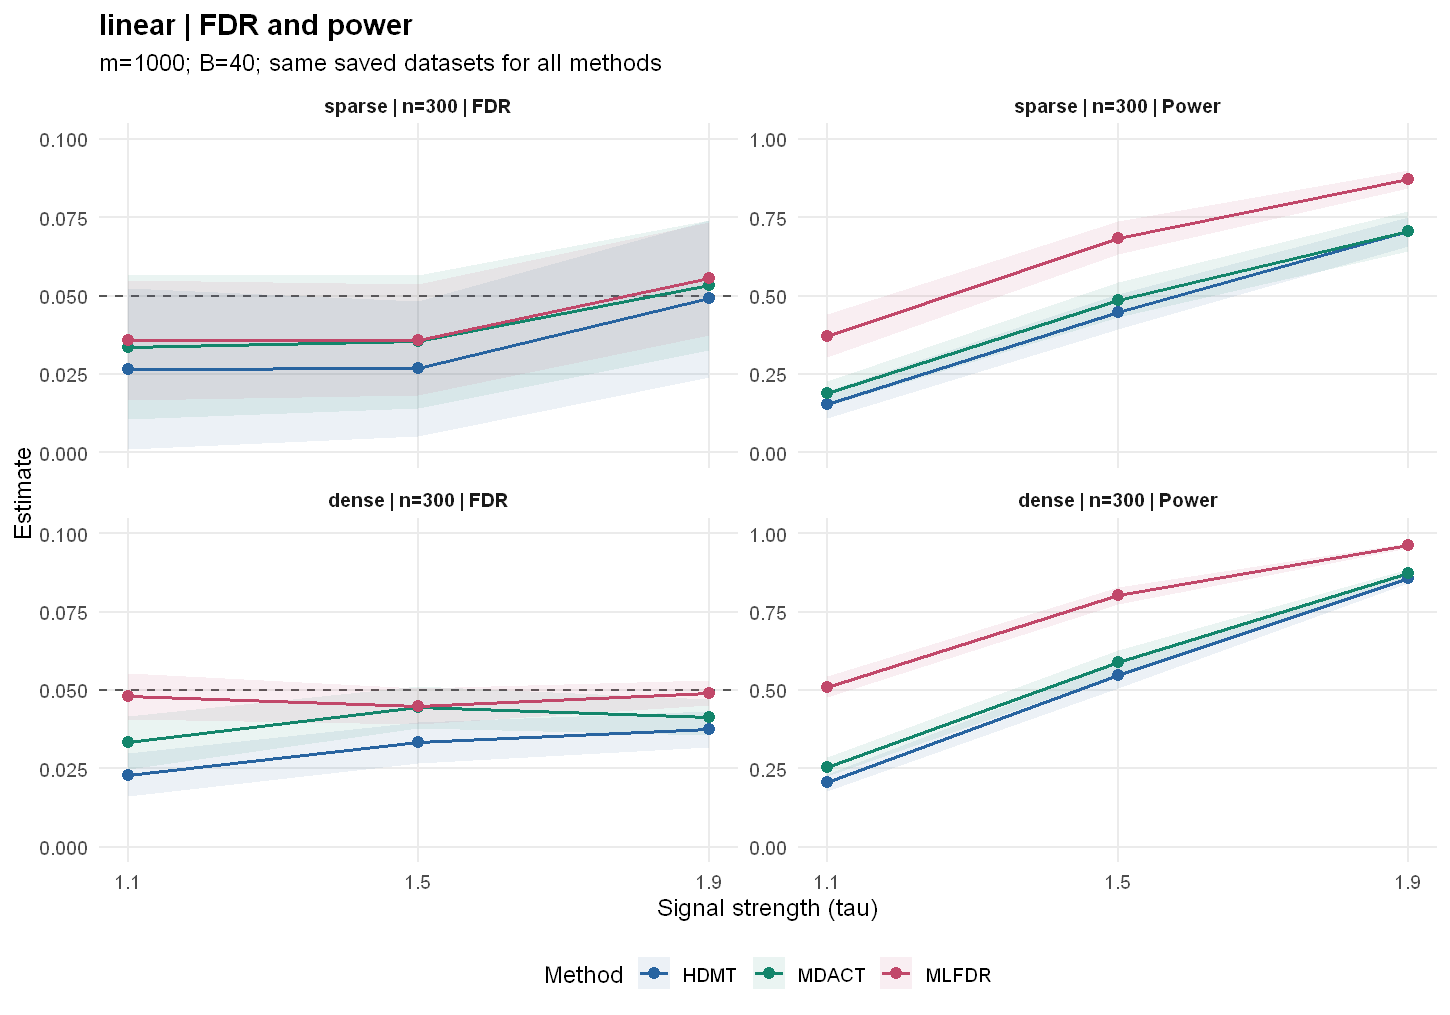

In [6]:
if ("linear" %in% config$scenarios) {
  print(plot_paper_comparison(summary_table, "linear"))
  table <- summary_table[summary_table$scenario == "linear",
       c("mixture", "n", "tau", "method", "n_success", "n_error", "n_warning", "FDR_mean", "FDR_mcse", "power_mean", "power_mcse")]
  numeric_cols <- vapply(table, is.numeric, logical(1))
  table[numeric_cols] <- lapply(table[numeric_cols], round, digits=4)
  IRdisplay::display(table)
}

## 已测混杂模型（论文图3的模型）

左列FDR、右列功效；上排稀疏、下排密集。虚线为q=0.05，功效轴保留0–1尺度。下表同时给出MCSE、成功数和警告数，不隐藏不利结果。模型结构对应论文，α均值已按前文增强。

,mixture,n,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
19,dense,300,1.1,HDMT,40,0,40,0.0183,0.0036,0.2012,0.0144
20,dense,300,1.1,MDACT,40,0,40,0.0352,0.0048,0.2523,0.0163
21,dense,300,1.1,MLFDR,40,0,0,0.0530,0.0042,0.5196,0.0155
22,dense,300,1.5,HDMT,40,0,40,0.0365,0.0033,0.5739,0.0205
23,dense,300,1.5,MDACT,40,0,40,0.0435,0.0035,0.6207,0.0178
24,dense,300,1.5,MLFDR,40,0,0,0.0515,0.0030,0.8210,0.0122
25,dense,300,1.9,HDMT,40,0,40,0.0375,0.0021,0.8515,0.0128
26,dense,300,1.9,MDACT,40,0,40,0.0377,0.0023,0.8616,0.0123
27,dense,300,1.9,MLFDR,40,0,0,0.0512,0.0020,0.9546,0.0052


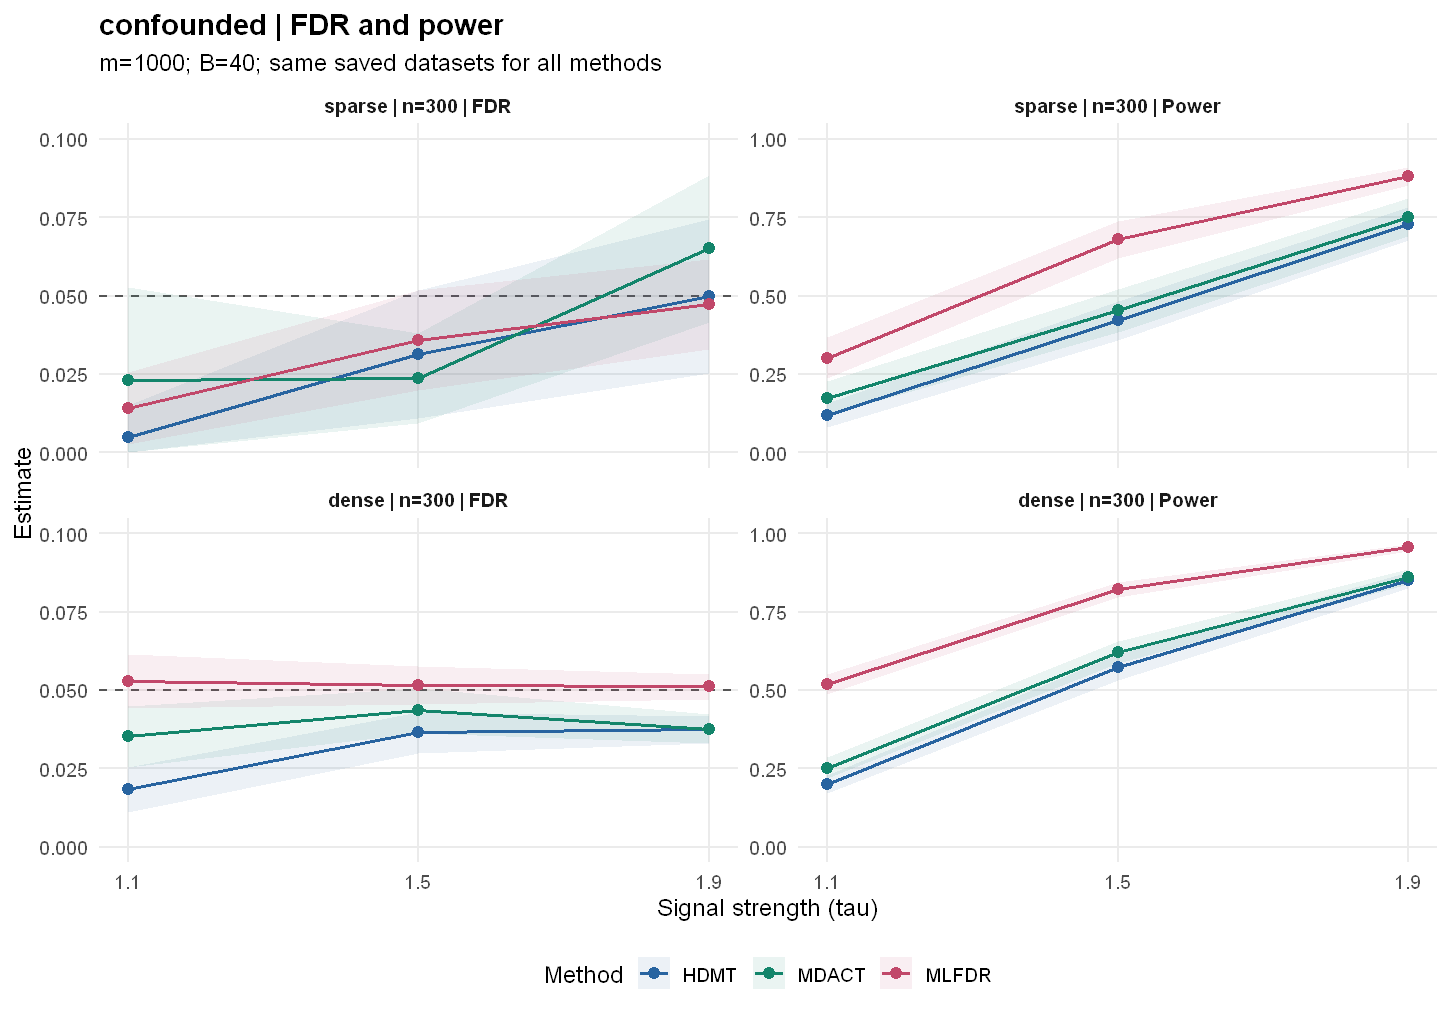

In [7]:
if ("confounded" %in% config$scenarios) {
  print(plot_paper_comparison(summary_table, "confounded"))
  table <- summary_table[summary_table$scenario == "confounded",
       c("mixture", "n", "tau", "method", "n_success", "n_error", "n_warning", "FDR_mean", "FDR_mcse", "power_mean", "power_mcse")]
  numeric_cols <- vapply(table, is.numeric, logical(1))
  table[numeric_cols] <- lapply(table[numeric_cols], round, digits=4)
  IRdisplay::display(table)
}

## 二元结局模型（论文图4的模型）

左列FDR、右列功效；上排稀疏、下排密集。虚线为q=0.05，功效轴保留0–1尺度。下表同时给出MCSE、成功数和警告数，不隐藏不利结果。模型结构对应论文，α均值已按前文增强。

,mixture,n,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,dense,300,1.1,HDMT,40,0,0,0.0159,0.0046,0.1443,0.0110
2,dense,300,1.1,MDACT,40,0,0,0.0265,0.0045,0.2233,0.0116
3,dense,300,1.1,MLFDR,40,0,0,0.0447,0.0033,0.4577,0.0117
4,dense,300,1.5,HDMT,40,0,0,0.0281,0.0029,0.5732,0.0149
5,dense,300,1.5,MDACT,40,0,0,0.0331,0.0030,0.6192,0.0133
6,dense,300,1.5,MLFDR,40,0,0,0.0476,0.0028,0.8213,0.0090
7,dense,300,1.9,HDMT,40,0,0,0.0448,0.0020,0.8202,0.0110
8,dense,300,1.9,MDACT,40,0,0,0.0481,0.0022,0.8362,0.0101
9,dense,300,1.9,MLFDR,40,0,0,0.0523,0.0026,0.9393,0.0048


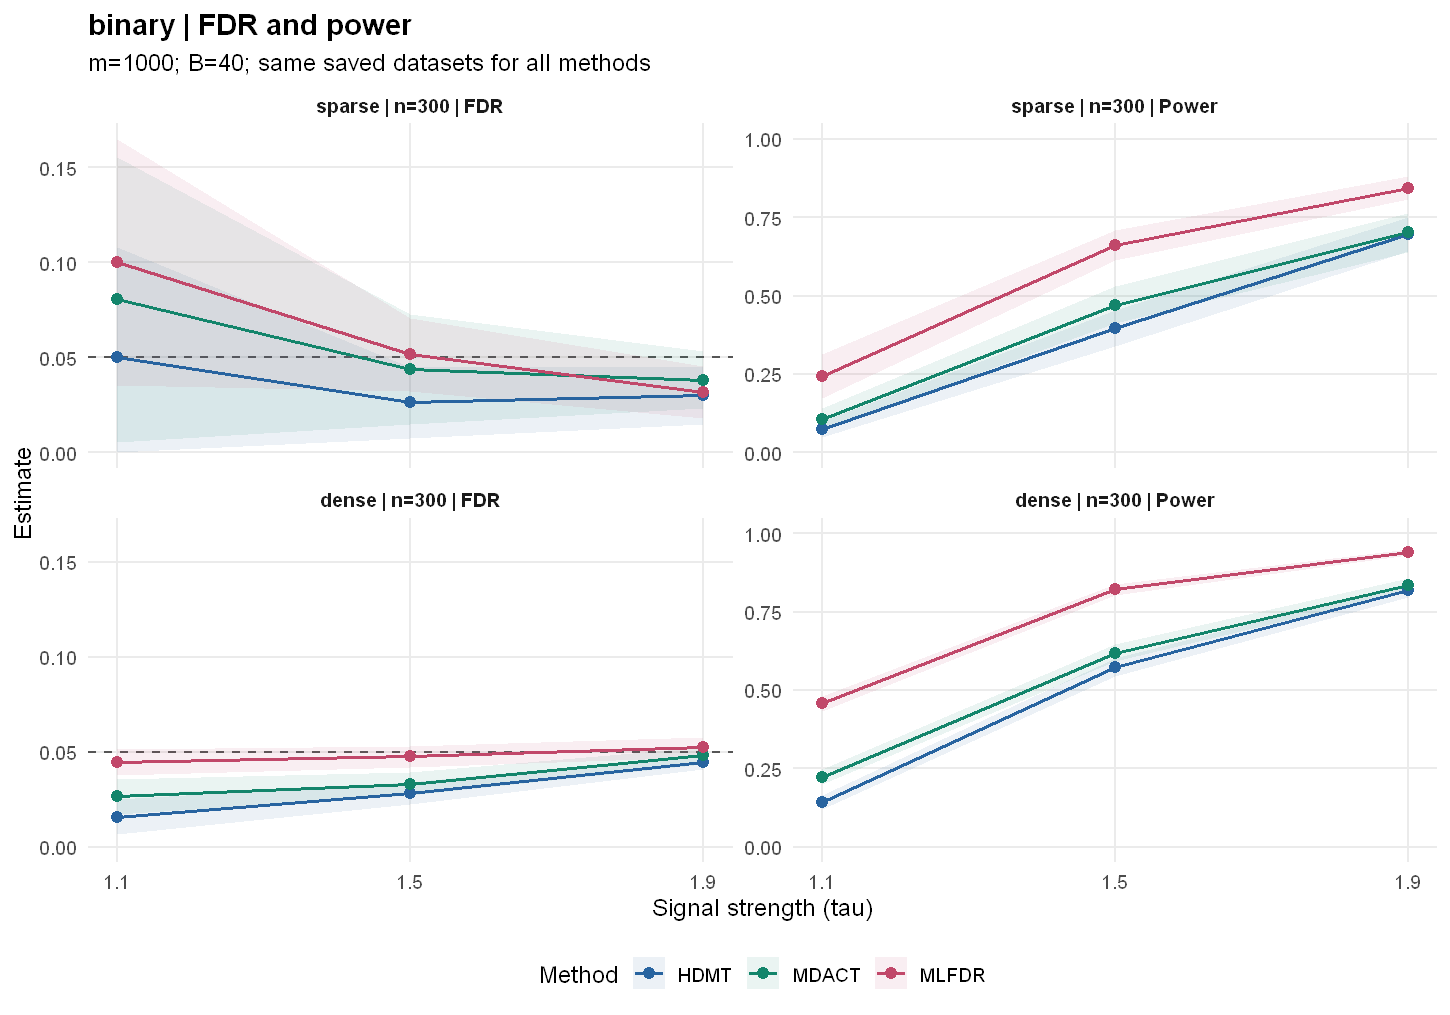

In [8]:
if ("binary" %in% config$scenarios) {
  print(plot_paper_comparison(summary_table, "binary"))
  table <- summary_table[summary_table$scenario == "binary",
       c("mixture", "n", "tau", "method", "n_success", "n_error", "n_warning", "FDR_mean", "FDR_mcse", "power_mean", "power_mcse")]
  numeric_cols <- vapply(table, is.numeric, logical(1))
  table[numeric_cols] <- lapply(table[numeric_cols], round, digits=4)
  IRdisplay::display(table)
}

## 同一数据下，功效相差多少

下表展示中间τ条件的配对差异：MLFDR减HDMT，以及MLFDR减MDACT，单位为**百分点**。例如10表示功效高0.10；不是相对提升10%。所有τ的完整表保存在`paired_differences.csv`。区间下限大于0支持本条件下稳定的功效差异；仍须同时查看FDR，不能单凭检出更多就判断更好。

In [9]:
paired <- artifacts$paired
middle_tau <- config$tau[ceiling(length(config$tau)/2)]
paired_display <- paired[paired$tau == middle_tau,
  c("scenario", "mixture", "n", "tau", "comparison", "n_pairs", "delta_power_mean", "delta_power_mcse", "delta_power_lo", "delta_power_hi")]
paired_display[, c("delta_power_mean", "delta_power_mcse", "delta_power_lo", "delta_power_hi")] <-
  round(100 * paired_display[, c("delta_power_mean", "delta_power_mcse", "delta_power_lo", "delta_power_hi")], 2)
paired_display

,scenario,mixture,n,tau,comparison,n_pairs,delta_power_mean,delta_power_mcse,delta_power_lo,delta_power_hi
,<chr>,<chr>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
7,binary,dense,300,1.5,MLFDR - HDMT,40,24.81,0.90,22.99,26.63
8,confounded,dense,300,1.5,MLFDR - HDMT,40,24.71,1.08,22.53,26.88
9,linear,dense,300,1.5,MLFDR - HDMT,40,25.43,1.02,23.37,27.50
10,binary,sparse,300,1.5,MLFDR - HDMT,40,26.51,2.41,21.64,31.39
11,confounded,sparse,300,1.5,MLFDR - HDMT,40,25.75,1.98,21.74,29.76
12,linear,sparse,300,1.5,MLFDR - HDMT,40,23.63,2.36,18.86,28.39
25,binary,dense,300,1.5,MLFDR - MDACT,40,20.21,0.73,18.73,21.69
26,confounded,dense,300,1.5,MLFDR - MDACT,40,20.03,0.81,18.40,21.66
27,linear,dense,300,1.5,MLFDR - MDACT,40,21.08,0.94,19.18,22.97


## 校准与拟合诊断

此处列出实际FDR区间下限高于q的条件，作为校准检查提示；近似区间和多条件检查不构成严格的联合显著性检验。EM不收敛和方法错误也会显示，不能把它们隐藏成零。完整记录见`diagnostics.csv`、`fit_diagnostics.csv`。

In [10]:
calibration_flags <- summary_table[is.finite(summary_table$FDR_lo) & summary_table$FDR_lo > config$q,
  c("scenario", "mixture", "n", "tau", "method", "FDR_mean", "FDR_mcse", "FDR_lo", "FDR_hi")]
if (nrow(calibration_flags)) IRdisplay::display(calibration_flags) else cat("没有条件的近似FDR区间下限高于目标q。\n")
fits <- artifacts$fits
if (!is.null(fits)) {
  cat("MLFDR收敛：", sum(fits$converged), "/", nrow(fits), "\n")
  cat("EM迭代数范围：", range(fits$iterations), "\n")
  print(head(fits, 6))
}
cat("功效配对区间下限>0的比较：", sum(paired$delta_power_lo > 0, na.rm=TRUE), "/", nrow(paired), "\n")

没有条件的近似FDR区间下限高于目标q。


MLFDR收敛： 720 / 720 
EM迭代数范围： 4 531 
                           case_id converged iterations        mu      theta
1     linear_sparse_n300_t01_r0001      TRUE          8 0.4162109 -0.5416579
2 confounded_sparse_n300_t01_r0001      TRUE        191 0.2569831 -0.5475830
3     binary_sparse_n300_t01_r0001      TRUE         65 0.2950567 -0.5492207
4      linear_dense_n300_t01_r0001      TRUE         25 0.3817204 -0.5400496
5  confounded_dense_n300_t01_r0001      TRUE         51 0.3729378 -0.5531951
6      binary_dense_n300_t01_r0001      TRUE         40 0.4093021 -0.5525256
        kappa         psi      pi00       pi10       pi01       pi11
1 0.000000000 0.017123126 0.9060370 0.03415842 0.03691323 0.02289138
2 0.035301399 0.010427861 0.8399937 0.09606876 0.03032485 0.03361266
3 0.000000000 0.006311218 0.8124224 0.11472168 0.05966516 0.01319075
4 0.000000000 0.012079594 0.4195174 0.16922682 0.20358525 0.20767053
5 0.007996370 0.014703630 0.3707839 0.22142994 0.20421418 0.20357202
6 0.0019190

功效配对区间下限>0的比较： 36 / 36 


## 查看一次真实决策

选择最大τ的密集线性条件第一重复，展示方法拒绝与模拟真值。此处是评估阶段；方法拟合没有接收这些状态。

In [11]:
design <- manifest$design
pick <- design[design$scenario == config$scenarios[1] & design$mixture == names(config$mixtures)[length(config$mixtures)] &
                design$n == max(config$n) & design$tau == max(config$tau) & design$replicate == 1, ]
selected_id <- pick$case_id[1]
selected_data <- read_dataset(manifest, selected_id)
selected_results <- get_case_results(experiment, selected_id, PROJECT_ROOT)
decision_table <- selected_data$truth[, c("pathway_id", "state", "is_nonnull")]
for (method in names(selected_results)) decision_table[[paste0("reject_", method)]] <- selected_results[[method]]$reject
write_csv(decision_table, file.path(experiment$output_dir, "example_decisions.csv"))
head(decision_table[Reduce(`|`, lapply(selected_results, function(x) x$reject)), ], 12)

,pathway_id,state,is_nonnull,reject_HDMT,reject_MDACT,reject_MLFDR
,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
5,pathway_0005,H11,TRUE,TRUE,TRUE,TRUE
19,pathway_0019,H11,TRUE,FALSE,TRUE,TRUE
32,pathway_0032,H11,TRUE,TRUE,TRUE,TRUE
38,pathway_0038,H11,TRUE,TRUE,TRUE,TRUE
52,pathway_0052,H11,TRUE,TRUE,TRUE,TRUE
58,pathway_0058,H01,FALSE,FALSE,FALSE,TRUE
60,pathway_0060,H11,TRUE,TRUE,TRUE,TRUE
62,pathway_0062,H11,TRUE,TRUE,TRUE,TRUE
64,pathway_0064,H11,TRUE,TRUE,TRUE,TRUE


## 加入新方法：即插即用

1. 复制`examples/new_method_template.R`到`R/methods/plugins/my_method.R`。
2. 实现`run(input, q, options)`，返回按原路径顺序的`list(reject=logical(m))`。需要原始数据时读取`input$raw`，需要系数时读取`input$estimates`；不要读取真值。
3. 在开头`config$methods`追加注册名，并在`config$method_options`设置参数；重新加载registry并运行实验。数据生成设置不变，原始数据和不变方法的缓存继续复用。

已提供可运行的`MaxP_BH`插件作为接口示例，默认不混入论文三方法比较。下面实际调用一次；它是保守基线，不能替代HDMT。接口和依赖/version规则见`docs/ADDING_METHODS.md`。

In [12]:
plugin_input <- make_method_input(selected_data, estimate_coefficients(selected_data)$estimates)
plugin_result <- registry$MaxP_BH$run(plugin_input, config$q, list())
invisible(validate_method_result(plugin_result, ncol(selected_data$M)))
data.frame(method="MaxP_BH", as.data.frame(compute_metrics(plugin_result$reject, selected_data$truth)))

method,discoveries,false_discoveries,true_discoveries,alternatives,FDP,power
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
MaxP_BH,157,2,155,193,0.01273885,0.8031088


## 修改、重跑和输出文件

- 开头参数区可改样本量、τ、混合比例、α/β效应、误差、重复数、q、方法和方法参数。先用较小重复数验证耗时，正式比较可增加到100或250。
- 严格字面正文参数：设置`config$dgp_profile <- "paper2026"`、`config$alpha_mean_scale <- .05`，并自行恢复论文的n/τ网格。功效可能再次很低；保持模型相同不意味着原图必然可由字面参数重现。
- 原包MLFDR：设`config$method_options$MLFDR <- list(engine="package", eps=.01, twostep=FALSE, verbose=FALSE)`。它的默认搜索范围可能不适合当前尺度，需明确记录。把两个后端作为额外比较对象时应注册不同标签。
- 改生成参数会进入新数据目录；只改q或新增方法可复用数据。方法或辅助文件有实质变化时更新适配器version，避免复用旧缓存。
- 已执行notebook可直接阅读；同名HTML无需R。`scripts/execute_notebook.py`会重跑并导出HTML；作者脚本`build_comparison_notebook.py`会覆盖手工改动及输出，日常调参不要运行它。

结果目录包含`replicate_metrics.csv`、`summary.csv`、`paired_differences.csv`、`fit_diagnostics.csv`、PNG、配置、环境和代码指纹。当前入口记录在`docs/current_comparison.rds`；运行与核查报告见`docs/COMPARISON_RUN_REPORT.md`。历史弱信号演示与开发试运行独立保留，不能与正式结果混合汇总。

本次比较只能支持所展示条件下的结果，不保证新方法、所有参数或真实数据中相同的排名。FDR控制理论是渐近性质；有限重复和有限样本仍需查看区间与校准诊断。